**WEEK 6 ASSIGNMENT** : Denoising Autoencoder on MNIST Dataset

**AUTOENCODERS**



In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Downloading dataset from kaggle

In [2]:
!pip install -q kaggle

In [3]:
import os

os.environ['KAGGLE_USERNAME'] = 'sunidhi031'
os.environ['KAGGLE_KEY'] = 'KGAT_69f3bf95fe0bda9508f8424df6c91a61'

In [4]:
!kaggle datasets list -s mnist


ref                                  title                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------  ---------------------------  ----------  --------------------------  -------------  ---------  ---------------  
zalando-research/fashionmnist        Fashion MNIST                  72114846  2017-12-07 00:54:20.537000         290764       3206  0.85294116       
hojjatk/mnist-dataset                MNIST  Dataset                 23112702  2019-01-08 13:01:57.983000         244428        769  0.75             
gpreda/chinese-mnist                 Chinese MNIST                  17261860  2021-03-28 09:44:55.430000          13473        275  0.9411765        
datamunge/sign-language-mnist        Sign Language MNIST            65633206  2017-10-20 15:09:18.850000         154645       1709  0.7647059        
oddrationale/mnist-in-csv            MNIST in CSV                   15970596  2018-05-19 02:24:20.88

In [5]:
!kaggle datasets download -d awsaf49/mnist-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/mnist-dataset
License(s): unknown
100% 28.6M/28.6M [00:00<00:00, 107MB/s] 



In [6]:
!unzip -q mnist-dataset.zip

In [7]:
!ls
!ls mnist_png
!ls mnist_png/training

mnist-dataset.zip  mnist_png  sample_data
testing  training
0  1  2  3  4  5  6  7	8  9


Importing liberaries

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array

Load Training Images

In [9]:
train_dir = "/content/mnist_png/training"
test_dir = "/content/mnist_png/testing"

IMG_SIZE = 28

x_train = []

for digit in os.listdir(train_dir):

    digit_folder = os.path.join(train_dir, digit)

    for img_name in os.listdir(digit_folder):

        img_path = os.path.join(digit_folder, img_name)

        img = load_img(
            img_path,
            color_mode='grayscale',
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        img = img_to_array(img) / 255.0

        x_train.append(img)

x_train = np.array(x_train)

print("Training Images Shape:", x_train.shape)

Training Images Shape: (60000, 28, 28, 1)


Load Test Images

In [10]:
x_test = []

for digit in os.listdir(test_dir):

    digit_folder = os.path.join(test_dir, digit)

    for img_name in os.listdir(digit_folder):

        img_path = os.path.join(digit_folder, img_name)

        img = load_img(
            img_path,
            color_mode='grayscale',
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        img = img_to_array(img) / 255.0

        x_test.append(img)

x_test = np.array(x_test)

print("Test Images Shape:", x_test.shape)

Test Images Shape: (10000, 28, 28, 1)


Visualizing Original Images

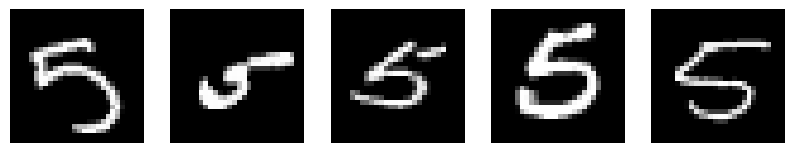

In [11]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

Adding Artificial Noise to crete noisy input images

In [12]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy training shape:", x_train_noisy.shape)
print("Noisy test shape:", x_test_noisy.shape)

Noisy training shape: (60000, 28, 28, 1)
Noisy test shape: (10000, 28, 28, 1)


Visualizing Original vs Noisy Images

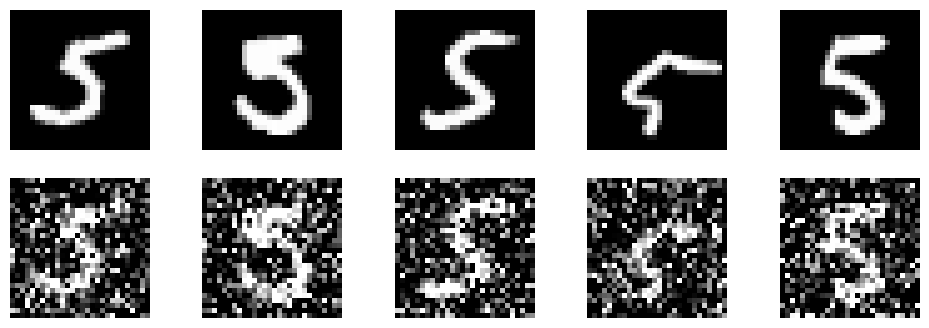

In [13]:
plt.figure(figsize=(12,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

STEP 3 : Building the Denoising Autoencoder

In [14]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#training the model
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1711 - val_loss: 0.1228
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1189 - val_loss: 0.1133
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1119 - val_loss: 0.1084
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1083 - val_loss: 0.1058
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1061 - val_loss: 0.1041
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1045 - val_loss: 0.1028
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1034 - val_loss: 0.1020
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1024 - val_loss: 0.1011
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1017 - val_loss: 0.1005
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1011 - val_loss: 0.1000


STEP 4 : Generate denoised outputs on the test set.

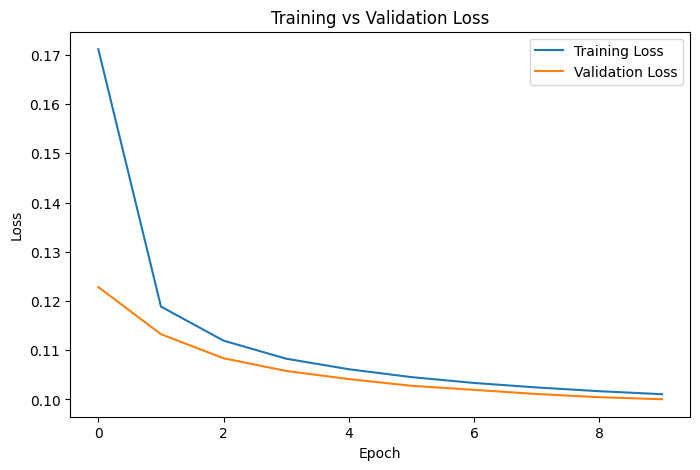

In [17]:
#validation Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [18]:
#Generate Denoised Images
decoded_imgs = autoencoder.predict(x_test_noisy)

print(decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(10000, 28, 28, 1)


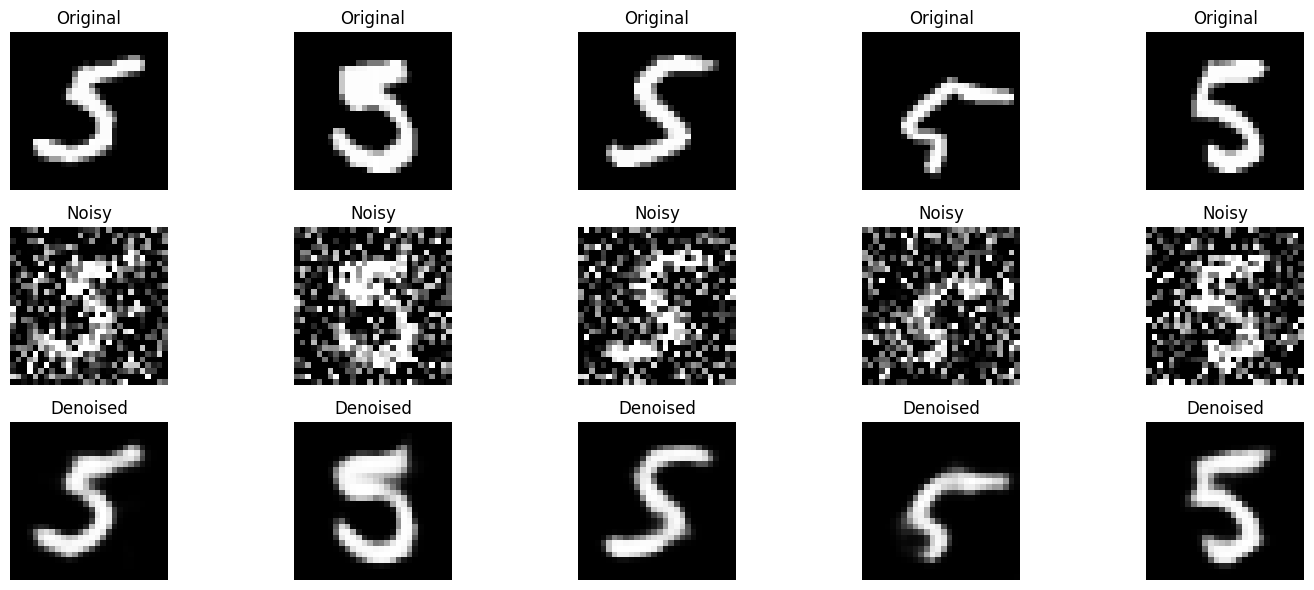

In [19]:
#Compare Original, Noisy and Denoised Images
n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

This project implements a Convolutional Denoising Autoencoder to remove noise from handwritten digit images. The MNIST image dataset obtained from Kaggle was used for training and testing.

Artificial noise was added to the original images to generate noisy inputs. The autoencoder consists of an encoder that extracts compressed feature representations and a decoder that reconstructs clean images from those features

After training for 10 epochs using the Adam optimizer and binary cross-entropy loss, the model successfully learned to remove noise and reconstruct recognizable digit images. The results demonstrate the effectiveness of autoencoders for image denoising tasks.



